In [10]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [8]:
from google.colab import files

In [2]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data mining for cybersecurity - data/Live GPS Spoofing and Jamming/UAV_Attack_Dataset_SUBSET.csv')

In [3]:
selected_features = ['control[0]',
    'control[1]',
    'control[2]',
    'control[3]',
    'vel_m_s',
    'vel_n_m_s',
   'vel_e_m_s',
   'vel_d_m_s',
   'gps_hvel[0]_var',
  'gps_hvel[0]_inn',
  'gps_hvel[1]_inn',
  'gps_vvel_inn',
  'gps_hpos[0]_inn',
  'gps_hpos[1]_inn']
data_subset = data[selected_features]

In [4]:
X = data_subset
y = data['class']

In [5]:
class_mapping = {
    'benign flight': 0,
    'gps jamming': 1,
    'gps spoofing': 2
    }

In [6]:
y = y.map(class_mapping)

In [7]:
# FEATURE ENGINEERING

print("FEATURE ENGINEERING")

# Control Signal Statistics
control_columns = [c for c in X.columns if 'control' in c]
if len(control_columns) > 1:
    X['control_std'] = X[control_columns].std(axis=1)

# GPS Variance Sum
variance_columns = [c for c in X.columns if '_var' in c]
if len(variance_columns) > 1:
    X['gps_var_sum'] = X[variance_columns].sum(axis=1)

# GPS Innovation Sum
innovation_columns = [c for c in X.columns if '_inn' in c]
if len(innovation_columns) > 1:
    X['gps_inn_sum'] = X[innovation_columns].abs().sum(axis=1)
    print("Created: gps_inn_sum (Sum of Absolute Innovations)")

print(f"\n Total features after engineering: {X.shape[1]}")

FEATURE ENGINEERING
Created: gps_inn_sum (Sum of Absolute Innovations)

 Total features after engineering: 16


/tmp/ipython-input-173/2959810596.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['control_std'] = X[control_columns].std(axis=1)
/tmp/ipython-input-173/2959810596.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['gps_inn_sum'] = X[innovation_columns].abs().sum(axis=1)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
svm_model = SVC(
    kernel='rbf',
    C=0.1,          # smaller C = stronger regularization
    gamma='scale',
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)

SVM Accuracy: 0.715702479338843

Classification Report:
                precision    recall  f1-score   support

benign flight       0.77      0.89      0.82       493
  gps jamming       0.65      0.67      0.66       444
 gps spoofing       0.73      0.48      0.58       273

     accuracy                           0.72      1210
    macro avg       0.72      0.68      0.69      1210
 weighted avg       0.71      0.72      0.71      1210


Confusion Matrix:
 [[438  46   9]
 [108 298  38]
 [ 25 118 130]]


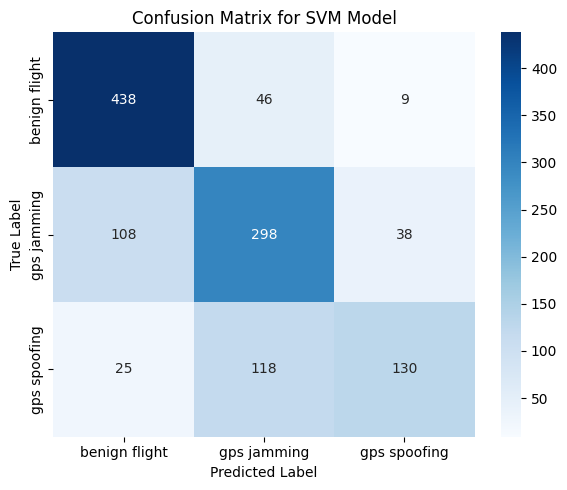

In [14]:
# Class labels
class_labels = ["benign flight", "gps jamming", "gps spoofing"]

print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_labels))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for SVM Model")
plt.tight_layout()
plt.show()

## Hyperparameter optimization & GridSearchCV

In [19]:
# 1. Define parameter grid

In [15]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

In [21]:
# 2. Define the model

In [16]:
svc = SVC(class_weight='balanced', random_state=42)

In [20]:
# 3. Initialize Grid Search (performs 5-fold cross-validation)

In [17]:
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, verbose=2, n_jobs=-1)

In [18]:
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=SVC(class_weight='balanced', random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.1, 0.01],
                         'kernel': ['rbf']},
             verbose=2)

In [22]:
# 5. Print best results
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Best parameters: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation score: 0.8621


In [23]:
# 6. Predict using the best model
best_model = grid_search.best_estimator_
y_pred_optimized = best_model.predict(X_test_scaled)

In [26]:
y_pred_train = best_model.predict(X_train_scaled)
ACC_SCORE_TRAIN = accuracy_score(y_train, y_pred_train)
print(f"Training Accuracy for the best model: {ACC_SCORE_TRAIN}")

Training Accuracy for the best model: 0.9253515301902399


In [24]:
# Report results
print("\n--- Improved Model Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred_optimized))
print("\nClassification Report:\n", classification_report(y_test, y_pred_optimized, target_names=class_labels))


--- Improved Model Results ---
Accuracy: 0.8826446280991735

Classification Report:
                precision    recall  f1-score   support

benign flight       0.88      0.92      0.90       493
  gps jamming       0.90      0.84      0.87       444
 gps spoofing       0.86      0.88      0.87       273

     accuracy                           0.88      1210
    macro avg       0.88      0.88      0.88      1210
 weighted avg       0.88      0.88      0.88      1210



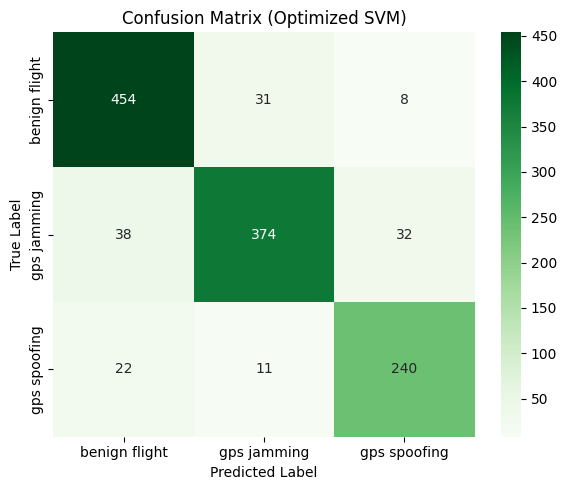

In [25]:
# Plot Confusion Matrix
cm_opt = confusion_matrix(y_test, y_pred_optimized)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_opt, annot=True, fmt="d", cmap="Greens", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Optimized SVM)")
plt.tight_layout()
plt.show()